# 03 - AG com Espaço de Busca Expandido (8 parâmetros do HistGB)

Expande o espaço de busca do `02_AG_threshold040.ipynb` de 5 para 8 parâmetros,
adicionando `max_depth`, `max_bins` e `min_impurity_decrease`.

| Notebook | Parâmetros | Combinações | Scorer |
|---|---|---|---|
| 01_AG | 5 | ~6.300 | threshold 0.5 (padrão) |
| 02 | 5 | ~6.300 | threshold 0.40 (operacional) |
| **03** | **8** | **~1.38M** | **threshold 0.40 (operacional)** |

Objetivo: verificar se um espaço de busca mais rico permite ao AG encontrar
configurações que reduzam FP e FN em relação ao baseline da Fase 1.

In [1]:
import gc
import json
import math
import os
import sys
import warnings
from pathlib import Path

# path setup antes de qualquer import local
_SRC_DIR = Path('../src').resolve()
if str(_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(_SRC_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import Parallel, delayed

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    f1_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.utils.class_weight import compute_sample_weight
from pipeline import apply_scenario

In [2]:
SRC_DIR = Path('../src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

warnings.filterwarnings('ignore')

RANDOM_STATE          = 42
CV_SPLITS             = 3
MIN_RECALL_THRESHOLD  = 0.80
OPERATIONAL_THRESHOLD = 0.40
SCENARIO              = 'B'

DATA_DIR      = Path('../data')
METRICS_DIR   = Path('../results/metrics')
ARTIFACTS_DIR = Path('../results/artifacts')
FIGURES_DIR   = Path('../results/figures')

def get_n_jobs(capacity: float = 0.80) -> int:
    return max(1, math.floor(os.cpu_count() * capacity))

# 4 cores reservados para uso do computador; divide o restante entre notebooks paralelos
N_JOBS = max(1, (os.cpu_count() - 4) // 2)
print(f'CPUs disponíveis : {os.cpu_count()}')
print(f'N_JOBS (03)     : {N_JOBS}  — reserva 4 cores para uso pessoal')

CPUs disponíveis : 12
N_JOBS (05c)     : 4  — reserva 4 cores para uso pessoal


In [3]:
def load_scenario_data(scenario: str) -> tuple:
    X_train_full = pd.read_parquet(DATA_DIR / 'X_train.parquet')
    X_test_full  = pd.read_parquet(DATA_DIR / 'X_test.parquet')
    y_train = pd.read_parquet(DATA_DIR / 'y_train.parquet').iloc[:, 0]
    y_test  = pd.read_parquet(DATA_DIR / 'y_test.parquet').iloc[:, 0]
    X_train = apply_scenario(X_train_full, scenario)
    X_test  = apply_scenario(X_test_full,  scenario)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_scenario_data(SCENARIO)
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('Distribuição y_train:', y_train.value_counts(normalize=True).round(3).to_dict())

X_train: (562520, 26)
X_test : (140630, 26)
Distribuição y_train: {0: 0.889, 1: 0.111}


## Baseline (RandomizedSearch Fase 1)

In [4]:
METRIC_NAMES = ['recall', 'f2', 'precision', 'roc_auc', 'average_precision', 'brier']

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'threshold':         float(threshold),
        'recall':            recall_score(y_true, y_pred, zero_division=0),
        'f2':                fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        'f1':                f1_score(y_true, y_pred, zero_division=0),
        'precision':         precision_score(y_true, y_pred, zero_division=0),
        'roc_auc':           roc_auc_score(y_true, y_prob),
        'average_precision': average_precision_score(y_true, y_prob),
        'brier':             brier_score_loss(y_true, y_prob),
    }

def evaluate_model_on_test(params: dict, threshold: float = OPERATIONAL_THRESHOLD) -> dict:
    sw = compute_sample_weight(class_weight='balanced', y=y_train)
    model = HistGradientBoostingClassifier(**params, random_state=RANDOM_STATE)
    model.fit(X_train, y_train, sample_weight=sw)
    y_prob = model.predict_proba(X_test)[:, 1]
    return compute_metrics(y_test, y_prob, threshold=threshold)

def load_baseline_params(metrics_dir: Path) -> dict:
    return json.loads((metrics_dir / 'best_model_operational_metrics.json').read_text())['best_params']

BASELINE_PARAMS = load_baseline_params(METRICS_DIR)
baseline_metrics = evaluate_model_on_test(BASELINE_PARAMS, threshold=OPERATIONAL_THRESHOLD)

print('=== BASELINE (Fase 1, threshold 0.40) ===')
for m in METRIC_NAMES:
    print(f'  {m:20s}: {baseline_metrics[m]:.4f}')
print(f'\nMeta: F2 > {baseline_metrics["f2"]:.4f} com recall >= {MIN_RECALL_THRESHOLD}')
gc.collect()

=== BASELINE (Fase 1, threshold 0.40) ===
  recall              : 0.9743
  f2                  : 0.3857
  precision           : 0.1129
  roc_auc             : 0.5773
  average_precision   : 0.1507
  brier               : 0.2436

Meta: F2 > 0.3857 com recall >= 0.8


24

## Scorers customizados (threshold 0.40)

`**kwargs` absorve argumentos extras que versões recentes do sklearn passam internamente ao scorer.

In [5]:
FITNESS_PENALTY = -1.0
_cv_strategy = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)

def _recall_at_operational(y_true, y_prob, **kwargs):
    return recall_score((y_prob >= OPERATIONAL_THRESHOLD).astype(int).__class__(y_true),
                        (y_prob >= OPERATIONAL_THRESHOLD).astype(int), zero_division=0)

def _recall_at_operational(y_true, y_prob, **kwargs):
    y_pred = (y_prob >= OPERATIONAL_THRESHOLD).astype(int)
    return recall_score(y_true, y_pred, zero_division=0)

def _f2_at_operational(y_true, y_prob, **kwargs):
    y_pred = (y_prob >= OPERATIONAL_THRESHOLD).astype(int)
    return fbeta_score(y_true, y_pred, beta=2, zero_division=0)

_recall_scorer_040 = make_scorer(_recall_at_operational, needs_proba=True)
_f2_scorer_040     = make_scorer(_f2_at_operational,     needs_proba=True)

def _cross_validate_recall_and_f2(model) -> tuple:
    mean_recall = cross_val_score(
        model, X_train, y_train, cv=_cv_strategy,
        scoring=_recall_scorer_040, n_jobs=1,
    ).mean()
    mean_f2 = cross_val_score(
        model, X_train, y_train, cv=_cv_strategy,
        scoring=_f2_scorer_040, n_jobs=1,
    ).mean()
    return float(mean_recall), float(mean_f2)

## Espaço de busca expandido (8 genes)

| Gene | Parâmetro | Valores | Qtd |
|---|---|---|---|
| 1 | `max_iter` | 100..500 | 8 |
| 2 | `learning_rate` | 0.01..0.20 | 7 |
| 3 | `max_leaf_nodes` | 15..127 | 7 |
| 4 | `min_samples_leaf` | 10..150 | 7 |
| 5 | `l2_regularization` | 0.0..5.0 | 7 |
| 6 | `max_depth` | None, 3..15 | 6 |
| 7 | `max_bins` | 63, 127, 255 | 3 |
| 8 | `min_impurity_decrease` | 0.0..0.01 | 4 |

**Total: ~1.38 milhão de combinações** (vs ~6.300 nos notebooks anteriores).

`max_depth=None` desativa o limite de profundidade (comportamento padrão do HistGB,
que ainda respeita `max_leaf_nodes`). `max_bins` controla a granularidade da
quantização das features contínuas — valores menores são mais rápidos mas menos precisos.

In [6]:
SEARCH_SPACE: dict = {
    'max_iter':          [100, 150, 200, 250, 300, 350, 400, 500],
    'learning_rate':     [0.01, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2],
    'max_leaf_nodes':    [15, 23, 31, 47, 63, 95, 127],
    'min_samples_leaf':  [10, 20, 35, 50, 75, 100, 150],
    'l2_regularization': [0.0, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0],
    'max_depth':         [None, 3, 5, 7, 10, 15],
    'max_bins':          [63, 127, 255],
}

PARAM_NAMES  = list(SEARCH_SPACE.keys())
PARAM_VALUES = list(SEARCH_SPACE.values())
N_GENES      = len(PARAM_NAMES)

total_combinations = 1
for v in PARAM_VALUES:
    total_combinations *= len(v)

def decode(individual: np.ndarray) -> dict:
    return {PARAM_NAMES[i]: PARAM_VALUES[i][individual[i]] for i in range(N_GENES)}

def random_individual(rng: np.random.Generator) -> np.ndarray:
    return np.array([rng.integers(0, len(v)) for v in PARAM_VALUES])

# max_iter=350→5, lr=0.05→2, max_leaf_nodes=31→2, min_samples_leaf=100→5
# l2=1.0→4, max_depth=None→0, max_bins=255→2
_baseline_individual = np.array([5, 2, 2, 5, 4, 0, 2])

print(f'Genes           : {N_GENES}')
print(f'Combinações     : {total_combinations:,}')
print(f'Baseline params : {decode(_baseline_individual)}')

Genes           : 7
Combinações     : 345,744
Baseline params : {'max_iter': 350, 'learning_rate': 0.05, 'max_leaf_nodes': 31, 'min_samples_leaf': 100, 'l2_regularization': 1.0, 'max_depth': None, 'max_bins': 255}


## Função fitness

In [7]:
def fitness(individual: np.ndarray, min_recall_threshold: float = MIN_RECALL_THRESHOLD) -> float:
    model = HistGradientBoostingClassifier(**decode(individual), random_state=RANDOM_STATE)
    mean_recall, mean_f2 = _cross_validate_recall_and_f2(model)
    return mean_f2 if mean_recall >= min_recall_threshold else mean_recall + FITNESS_PENALTY

In [8]:
# Baseline deve passar o piso de 0.80 com scorer threshold 0.40
_baseline_cv_recall, _baseline_cv_f2 = _cross_validate_recall_and_f2(
    HistGradientBoostingClassifier(**BASELINE_PARAMS, random_state=RANDOM_STATE)
)
print(f'CV recall (threshold 0.40): {_baseline_cv_recall:.4f}  piso 0.80: {"PASSA" if _baseline_cv_recall >= 0.80 else "FALHA"}')
print(f'CV F2   (threshold 0.40): {_baseline_cv_f2:.4f}')
print(f'Fitness baseline: {fitness(_baseline_individual):.4f}')

CV recall (threshold 0.40): 0.0032  piso 0.80: FALHA
CV F2   (threshold 0.40): 0.0041
Fitness baseline: -0.9968


## Operadores genéticos

In [9]:
def tournament_selection(population, fitnesses, tournament_size, rng):
    candidates   = rng.choice(len(population), size=tournament_size, replace=False)
    winner_index = candidates[np.argmax([fitnesses[i] for i in candidates])]
    return population[winner_index].copy()

def single_point_crossover(parent_a, parent_b, crossover_rate, rng):
    if rng.random() > crossover_rate:
        return parent_a.copy(), parent_b.copy()
    cut = rng.integers(1, N_GENES)
    return (
        np.concatenate([parent_a[:cut], parent_b[cut:]]),
        np.concatenate([parent_b[:cut], parent_a[cut:]]),
    )

def mutate(individual, mutation_rate, rng):
    mutated = individual.copy()
    for i in range(N_GENES):
        if rng.random() < mutation_rate:
            mutated[i] = rng.integers(0, len(PARAM_VALUES[i]))
    return mutated

## Loop principal do AG

In [10]:
def _initialize_population(pop_size: int, rng: np.random.Generator, seed_individual=None) -> list:
    pop = [seed_individual.copy()] if seed_individual is not None else []
    pop += [random_individual(rng) for _ in range(pop_size - len(pop))]
    return pop

def _evaluate_population(population: list, min_recall_threshold: float = MIN_RECALL_THRESHOLD) -> list:
    return Parallel(n_jobs=N_JOBS)(
        delayed(fitness)(ind, min_recall_threshold) for ind in population
    )

def _breed_next_generation(population, fitnesses, pop_size, elite_size,
                           tournament_size, crossover_rate, mutation_rate, rng):
    sorted_idx  = np.argsort(fitnesses)[::-1]
    next_gen    = [population[i].copy() for i in sorted_idx[:elite_size]]
    while len(next_gen) < pop_size:
        pa = tournament_selection(population, fitnesses, tournament_size, rng)
        pb = tournament_selection(population, fitnesses, tournament_size, rng)
        ca, cb = single_point_crossover(pa, pb, crossover_rate, rng)
        next_gen.append(mutate(ca, mutation_rate, rng))
        if len(next_gen) < pop_size:
            next_gen.append(mutate(cb, mutation_rate, rng))
    return next_gen

def run_genetic_algorithm(
    pop_size=20, n_generations=15, mutation_rate=0.20, crossover_rate=0.80,
    tournament_size=3, elite_size=1, seed=RANDOM_STATE, label='AG',
    min_recall_threshold=MIN_RECALL_THRESHOLD, seed_individual=None,
) -> dict:
    rng        = np.random.default_rng(seed)
    population = _initialize_population(pop_size, rng, seed_individual)
    best_individual, best_fitness_ever = None, -np.inf
    history_rows = []

    for gen in range(1, n_generations + 1):
        fitnesses = _evaluate_population(population, min_recall_threshold)
        best_idx  = int(np.argmax(fitnesses))
        best_fit  = fitnesses[best_idx]
        if best_fit > best_fitness_ever:
            best_fitness_ever = best_fit
            best_individual   = population[best_idx].copy()
        history_rows.append({
            'generation':   gen,
            'best_fitness': best_fit,
            'mean_fitness': float(np.mean(fitnesses)),
            'best_params':  decode(population[best_idx]),
        })
        print(f'[{label}] Gen {gen}/{n_generations} | melhor={best_fit:.4f} | média={np.mean(fitnesses):.4f}')
        population = _breed_next_generation(
            population, fitnesses, pop_size, elite_size,
            tournament_size, crossover_rate, mutation_rate, rng,
        )

    return {
        'label':           label,
        'best_params':     decode(best_individual),
        'best_cv_fitness': best_fitness_ever,
        'history':         pd.DataFrame(history_rows),
    }

In [11]:
_smoke = run_genetic_algorithm(pop_size=4, n_generations=2, label='smoke_03', seed=RANDOM_STATE)
print('\nSmoke OK | params:', _smoke['best_params'])
print(f'Fitness : {_smoke["best_cv_fitness"]:.4f}')

[smoke_05c] Gen 1/2 | melhor=-0.9965 | média=-0.9967
[smoke_05c] Gen 2/2 | melhor=-0.9965 | média=-0.9965

Smoke OK | params: {'max_iter': 350, 'learning_rate': 0.15, 'max_leaf_nodes': 63, 'min_samples_leaf': 50, 'l2_regularization': 2.0, 'max_depth': 15, 'max_bins': 127}
Fitness : -0.9965


## Experimentos — espaço expandido | recall >= 0.80 | threshold 0.40

Mesmas 4 configurações de AG dos notebooks anteriores para comparação direta.
O hot start usa o baseline da Fase 1 como semente, codificado nos 8 genes.

| Experimento | pop_size | n_generations | mutation_rate | crossover_rate | Perfil |
|---|---|---|---|---|---|
| Exp1 | 10 | 8 | 0.10 | 0.70 | Conservador |
| Exp2 | 20 | 15 | 0.20 | 0.80 | Padrão |
| Exp3 | 20 | 15 | 0.40 | 0.80 | Exploratório |
| Exp4 | 20 | 15 | 0.20 | 0.80 | Hot start (seed = baseline Fase 1) |

In [12]:
RECALL_SCENARIOS  = [0.80]

EXPERIMENT_CONFIGS = [
    dict(pop_size=8, n_generations=8,  mutation_rate=0.10, crossover_rate=0.70, label='Exp1_conservador'),
    dict(pop_size=8, n_generations=8,  mutation_rate=0.20, crossover_rate=0.80, label='Exp2_padrao'),
    dict(pop_size=8, n_generations=8,  mutation_rate=0.40, crossover_rate=0.80, label='Exp3_exploratorio'),
    dict(pop_size=8, n_generations=8,  mutation_rate=0.20, crossover_rate=0.80,
         label='Exp4_hotstart', seed_individual=_baseline_individual),
]

In [13]:
scenario_results: dict = {}

for recall_threshold in RECALL_SCENARIOS:
    print(f'\n{"#"*60}')
    print(f'# CENÁRIO: recall >= {recall_threshold} | espaço 8 genes | scorer 0.40')
    print(f'{"#"*60}')
    experiment_results = {}
    for config in EXPERIMENT_CONFIGS:
        print(f'\n{"="*60}\nIniciando {config["label"]}\n{"="*60}')
        result = run_genetic_algorithm(**config, min_recall_threshold=recall_threshold, seed=RANDOM_STATE)
        experiment_results[config['label']] = result
        print(f'Params : {result["best_params"]}')
        print(f'Fitness: {result["best_cv_fitness"]:.4f}')
    scenario_results[recall_threshold] = experiment_results


############################################################
# CENÁRIO: recall >= 0.8 | espaço 8 genes | scorer 0.40
############################################################

Iniciando Exp1_conservador
[Exp1_conservador] Gen 1/8 | melhor=-0.9960 | média=-0.9970
[Exp1_conservador] Gen 2/8 | melhor=-0.9960 | média=-0.9964
[Exp1_conservador] Gen 3/8 | melhor=-0.9960 | média=-0.9962
[Exp1_conservador] Gen 4/8 | melhor=-0.9960 | média=-0.9960
[Exp1_conservador] Gen 5/8 | melhor=-0.9960 | média=-0.9962
[Exp1_conservador] Gen 6/8 | melhor=-0.9960 | média=-0.9960
[Exp1_conservador] Gen 7/8 | melhor=-0.9960 | média=-0.9962
[Exp1_conservador] Gen 8/8 | melhor=-0.9960 | média=-0.9961
Params : {'max_iter': 200, 'learning_rate': 0.2, 'max_leaf_nodes': 95, 'min_samples_leaf': 20, 'l2_regularization': 0.5, 'max_depth': 15, 'max_bins': 63}
Fitness: -0.9960

Iniciando Exp2_padrao
[Exp2_padrao] Gen 1/8 | melhor=-0.9960 | média=-0.9970
[Exp2_padrao] Gen 2/8 | melhor=-0.9958 | média=-0.9963
[Exp2_pad

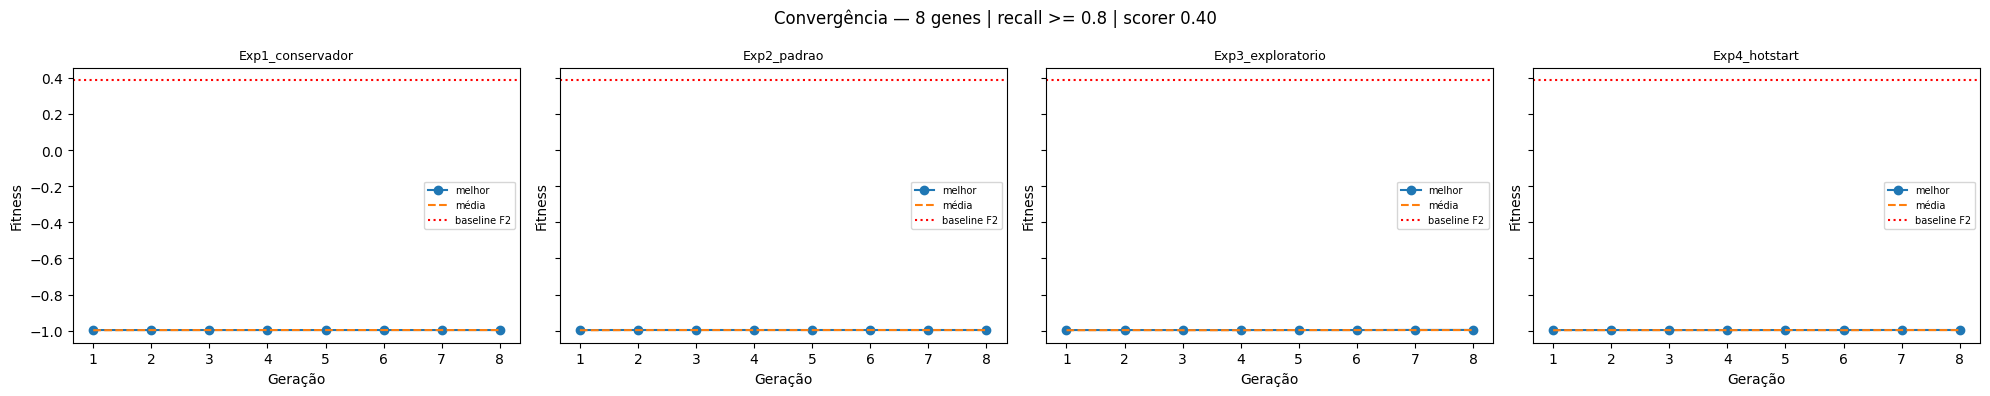

In [14]:
for recall_threshold, experiment_results in scenario_results.items():
    n_exp = len(experiment_results)
    fig, axes = plt.subplots(1, n_exp, figsize=(5 * n_exp, 4), sharey=True)
    if n_exp == 1:
        axes = [axes]
    for ax, (label, result) in zip(axes, experiment_results.items()):
        h = result['history']
        ax.plot(h['generation'], h['best_fitness'], marker='o', label='melhor')
        ax.plot(h['generation'], h['mean_fitness'], linestyle='--', label='média')
        ax.axhline(baseline_metrics['f2'], color='red', linestyle=':', linewidth=1.5, label='baseline F2')
        ax.set_title(label, fontsize=9)
        ax.set_xlabel('Geração')
        ax.set_ylabel('Fitness')
        ax.legend(fontsize=7)
    plt.suptitle(f'Convergência — 8 genes | recall >= {recall_threshold} | scorer 0.40', fontsize=12)
    plt.tight_layout()
    fname = f'03_convergence_8genes_recall{str(recall_threshold).replace(".", "")}.png'
    plt.savefig(FIGURES_DIR / fname, dpi=150)
    plt.show()

## Comparativo: baseline vs AG com espaço expandido

In [15]:
def build_row(label, params, cv_fitness):
    m = evaluate_model_on_test(params, threshold=OPERATIONAL_THRESHOLD)
    return {'origem': label, 'cv_fitness': round(cv_fitness, 4),
            **{k: m[k] for k in METRIC_NAMES}}

scenario_comparison_dfs: dict = {}

for recall_threshold, experiment_results in scenario_results.items():
    rows = [
        build_row('Baseline (Fase 1)', BASELINE_PARAMS, fitness(_baseline_individual, recall_threshold)),
        *[build_row(lbl, res['best_params'], res['best_cv_fitness'])
          for lbl, res in experiment_results.items()]
    ]
    df = pd.DataFrame(rows).set_index('origem')
    scenario_comparison_dfs[recall_threshold] = df
    print(f'\n=== Espaço 8 genes | scorer 0.40 | recall >= {recall_threshold} ===')
    display(df.round(4))
    fname = f'03_comparison_8genes_recall{str(recall_threshold).replace(".", "")}.csv'
    df.to_csv(METRICS_DIR / fname)
    print(f'Salvo: {METRICS_DIR / fname}')

gc.collect()


=== Espaço 8 genes | scorer 0.40 | recall >= 0.8 ===


,cv_fitness,recall,f2,precision,roc_auc,average_precision,brier
origem,,,,,,,
Baseline (Fase 1),-0.9968,0.9743,0.3857,0.1129,0.5773,0.1507,0.2436
Exp1_conservador,-0.9960,0.9414,0.3864,0.1151,0.5790,0.1525,0.2404
Exp2_padrao,-0.9958,0.9295,0.3860,0.1156,0.5802,0.1546,0.2386
Exp3_exploratorio,-0.9954,0.9441,0.3851,0.1143,0.5778,0.1529,0.2403
Exp4_hotstart,-0.9958,0.9494,0.3854,0.1142,0.5778,0.1521,0.2411


Salvo: ../../results/metrics/05c_comparison_8genes_recall08.csv


79

In [16]:
MAX_FP_GROWTH_PCT = 0.15
MAX_FN_GROWTH_PCT = 0.30
MIN_RECALL_TEST   = 0.80

for recall_threshold, comparison_df in scenario_comparison_dfs.items():
    print(f'\n{"="*60}')
    print(f'=== Conclusão — 8 genes | scorer 0.40 | recall >= {recall_threshold} ===')
    print(f'{"="*60}')
    baseline_row   = comparison_df.loc['Baseline (Fase 1)']
    best_exp       = comparison_df.drop('Baseline (Fase 1)').sort_values('f2', ascending=False).iloc[0]
    delta_f2       = best_exp['f2'] - baseline_row['f2']
    delta_recall   = best_exp['recall'] - baseline_row['recall']
    n_pos          = int(y_test.sum())
    fn_base        = int(n_pos * (1 - baseline_row['recall']))
    fn_ag          = int(n_pos * (1 - best_exp['recall']))
    tp_base        = n_pos - fn_base
    tp_ag          = n_pos - fn_ag
    fp_base        = int(tp_base / max(baseline_row['precision'], 1e-9) - tp_base)
    fp_ag          = int(tp_ag   / max(best_exp['precision'],    1e-9) - tp_ag)
    fp_growth      = (fp_ag - fp_base) / max(fp_base, 1)
    fn_growth      = (fn_ag - fn_base) / max(abs(fn_base), 1)
    recall_ok      = best_exp['recall'] >= MIN_RECALL_TEST
    fn_ok          = fn_growth <= MAX_FN_GROWTH_PCT
    fp_ok          = fp_growth <= MAX_FP_GROWTH_PCT
    validacao_ok   = recall_ok and fn_ok and fp_ok
    print(f'Melhor AG : {best_exp.name}')
    print(f'F2        : {best_exp["f2"]:.4f}  (baseline {baseline_row["f2"]:.4f} | delta {delta_f2:+.4f})')
    print(f'Recall    : {best_exp["recall"]:.4f}  (baseline {baseline_row["recall"]:.4f} | delta {delta_recall:+.4f})')
    print(f'ROC-AUC   : {best_exp["roc_auc"]:.4f}  (baseline {baseline_row["roc_auc"]:.4f})')
    print(f'\nFN baseline={fn_base:,}  FN AG={fn_ag:,}  crescimento={fn_growth:+.1%}')
    print(f'FP baseline={fp_base:,}  FP AG={fp_ag:,}  crescimento={fp_growth:+.1%}')
    print(f'\nValidação clínica:')
    print(f'  Recall >= {MIN_RECALL_TEST}     : {"OK" if recall_ok else "FALHA"}')
    print(f'  FN cresce <= {MAX_FN_GROWTH_PCT:.0%} : {"OK" if fn_ok else "FALHA"}  ({fn_growth:+.1%})')
    print(f'  FP cresce <= {MAX_FP_GROWTH_PCT:.0%} : {"OK" if fp_ok else "FALHA"}  ({fp_growth:+.1%})')
    print(f'\nPivô: {"APROVADO" if validacao_ok else "REPROVADO"} — delta F2 = {delta_f2:+.4f}')


=== Conclusão — 8 genes | scorer 0.40 | recall >= 0.8 ===
Melhor AG : Exp1_conservador
F2        : 0.3864  (baseline 0.3857 | delta +0.0007)
Recall    : 0.9414  (baseline 0.9743 | delta -0.0329)
ROC-AUC   : 0.5790  (baseline 0.5773)

FN baseline=399  FN AG=912  crescimento=+128.6%
FP baseline=119,197  FP AG=112,717  crescimento=-5.4%

Validação clínica:
  Recall >= 0.8     : OK
  FN cresce <= 30% : FALHA  (+128.6%)
  FP cresce <= 15% : OK  (-5.4%)

Pivô: REPROVADO — delta F2 = +0.0007
